In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK174"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47

# symmetrical shape

In [2]:
name_dict = dict(
    data1 = dict(amp=0.2, date="2025-02-20", acquire_time="115134", params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.3, date="2025-02-20", acquire_time="121305", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)),
    data25 = dict(amp=0.35, date="2025-02-20", acquire_time="122035", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data3 = dict(amp=0.4, date="2025-02-20", acquire_time="123118", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data35 = dict(amp=0.425, date="2025-02-20", acquire_time="124210", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data4
    # data4 = dict(amp=0.5, date="2025-02-18", acquire_time="155452", params=dict(fit_start=140, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
)

# Generating Control Pulses

0.2 2025-02-20 115134
0.3 2025-02-20 121305
0.35 2025-02-20 122035
0.4 2025-02-20 123118
0.425 2025-02-20 124210


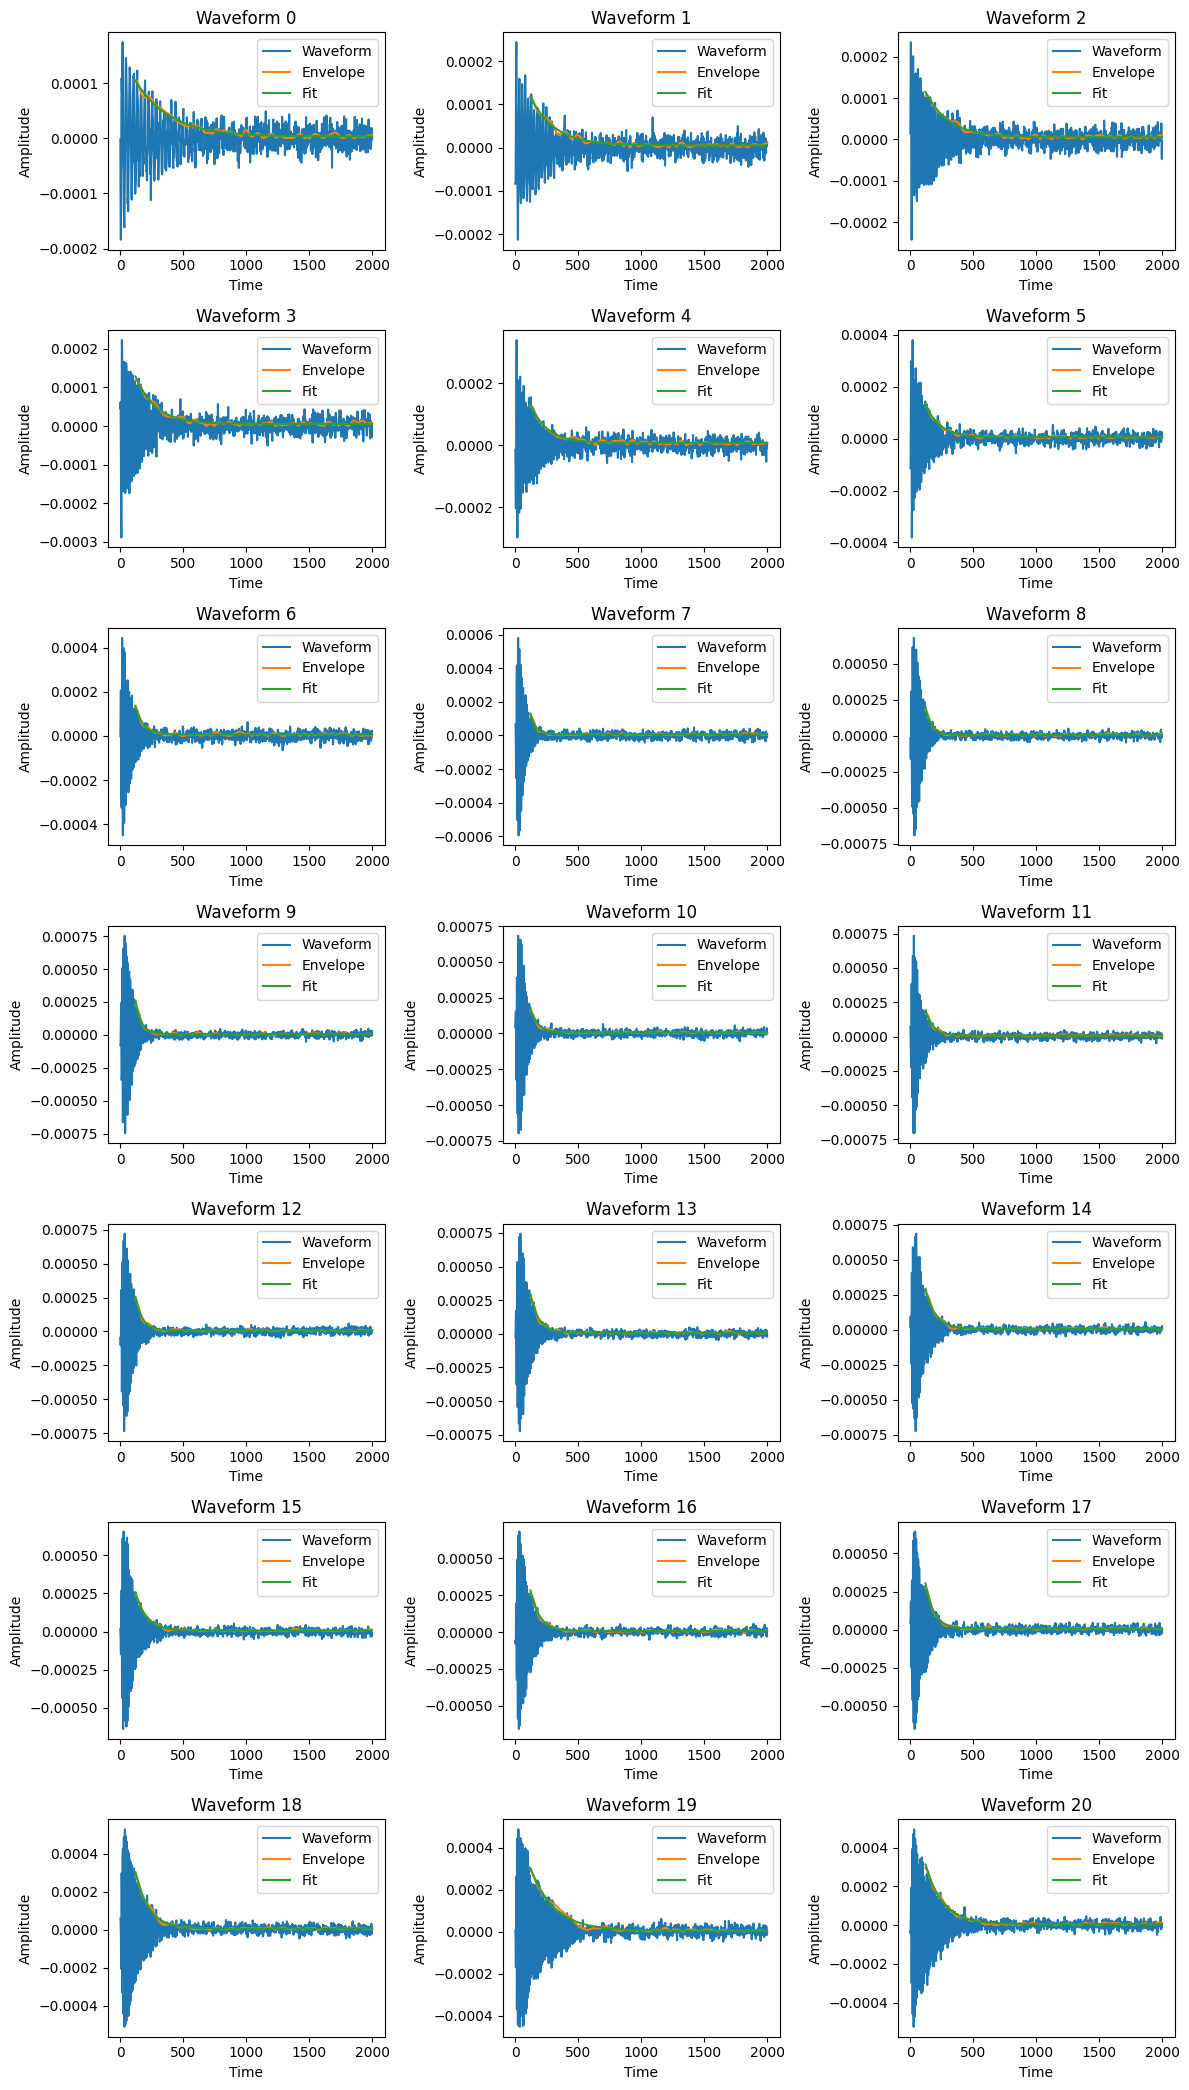

In [3]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

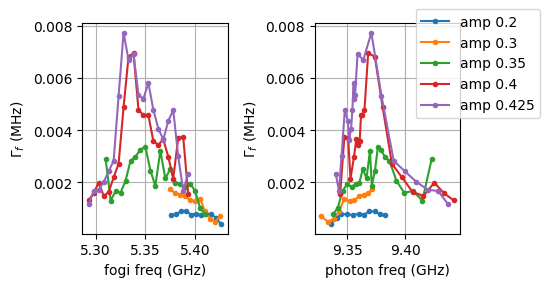

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.999992

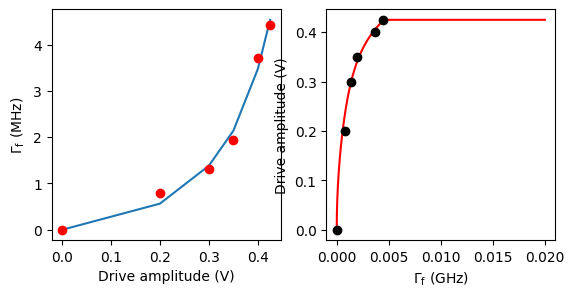

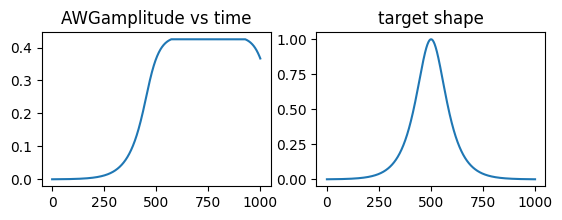

[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.99999291e-01
 9.99999264e-01 9.99999236e-01 9.99999206e-01 9.99999176e-01
 9.99999145e-01 9.99999113e-01 9.99999079e-01 9.99999045e-01
 9.99999010e-01 9.999989

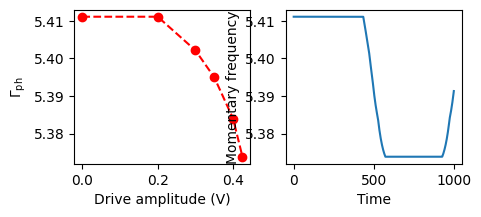

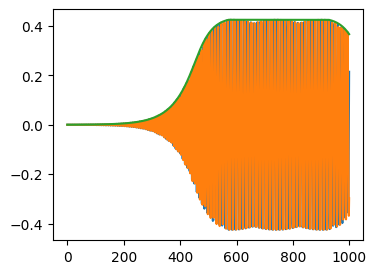

In [4]:
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.29, target_freq, duration, const=const, form="sech_0", tr=False)[0]

## save

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.999992

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


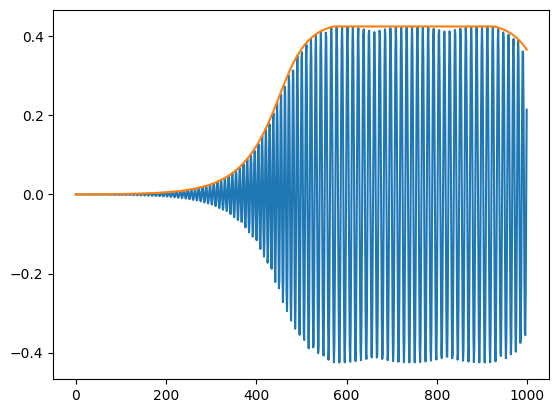

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


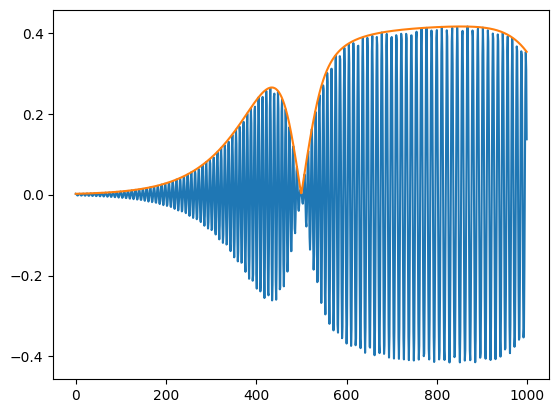

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


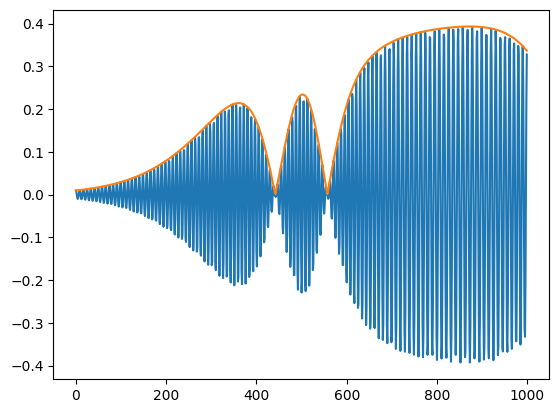

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


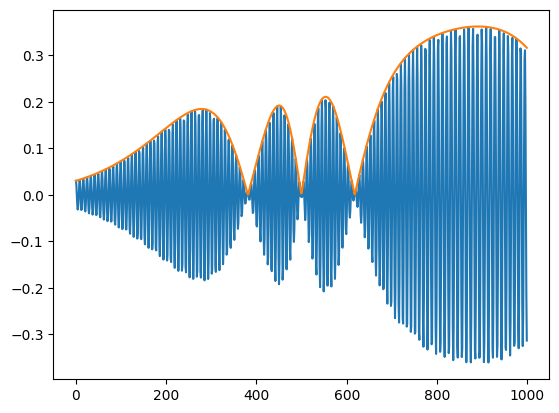

In [5]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
forms = ["sech_0", "sech_1", "sech_2", "sech_3"] 

for form in forms:
    for target_freq in [9.35]:
        control_pulse, control_envelope = dataobj.generate_control_pulse(
            5.29, target_freq, duration, const=const, form=form, plot=False, tr=False
        )

        plt.plot(control_pulse)
        plt.plot(control_envelope)
        plt.show()
        # note = f"""
        # form : {form}
        # const : {const / 2 / np.pi}
        # duration : {duration}
        # target frequency : {target_freq} GHz
        # """

        # data = DataDict(
        #     time=dict(unit="ns"),
        #     control_pulse=dict(axes=["time"]),
        #     control_envelope=dict(axes=["time"])
        # )
        # data.validate()

        # save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        # with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
        #     writer.add_tag(["control_pulse", cd, form])
        #     writer.save_text("target_shape.md", note)
        #     writer.add_data(
        #         time=np.arange(len(control_pulse)),
        #         control_pulse=control_pulse,
        #         control_envelope=control_envelope
        #     )
        # T.sleep(1)


# Photon shaping analysis

In [2]:
from Analysis import SechPhotonAnalysis
import numpy as np
import matplotlib.pyplot as plt
cd = "CDK174"

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Form: sech_0, Symmetry: 0.5455877452853546, Overlap: 0.9930061323723021
Form: sech_1, Symmetry: 0.12219980911815212, Overlap: 0.9880835365980756
Form: sech_2, Symmetry: 0.2058574730776309, Overlap: 0.9778384565040475
Form: sech_3, Symmetry: 0.1726809277875398, Overlap: 0.9689263003485501


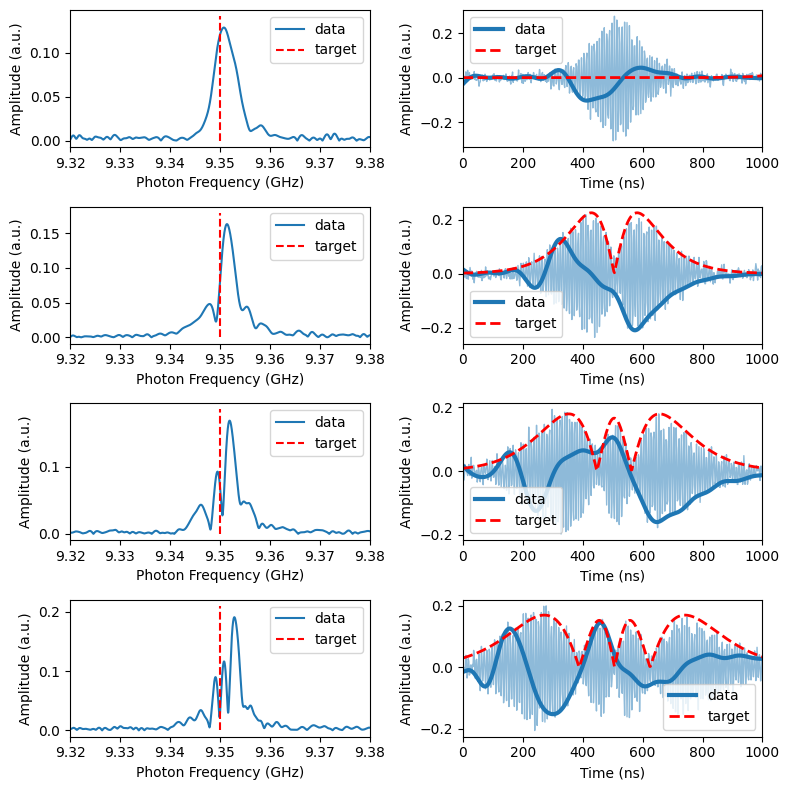

In [3]:
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.47
duration = 1000
passing_band = 0.01
const = 2.5e-3*2*np.pi
result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="102937", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="103014", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="103050", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="103127", form="sech_3"),
}

analyzer = SechPhotonAnalysis(data_path, result_dict, duration, const, readout_lo_freq)
analyzer.analyze_waveforms(passing_band)

phase subtraction

In [4]:
ctrl_pulse_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\"
# analyzer.phase_subtraction_and_pulse_flip(ctrl_pulse_path)

corrected photon shaping

Form: sech_0, Symmetry: 0.9782520176832245, Overlap: 0.9947987046709694
Form: sech_1, Symmetry: 0.9303909551427757, Overlap: 0.9916892841559959
Form: sech_2, Symmetry: 0.9002953450362546, Overlap: 0.9876555089895067
Form: sech_3, Symmetry: 0.8323495620693577, Overlap: 0.9696410391538908


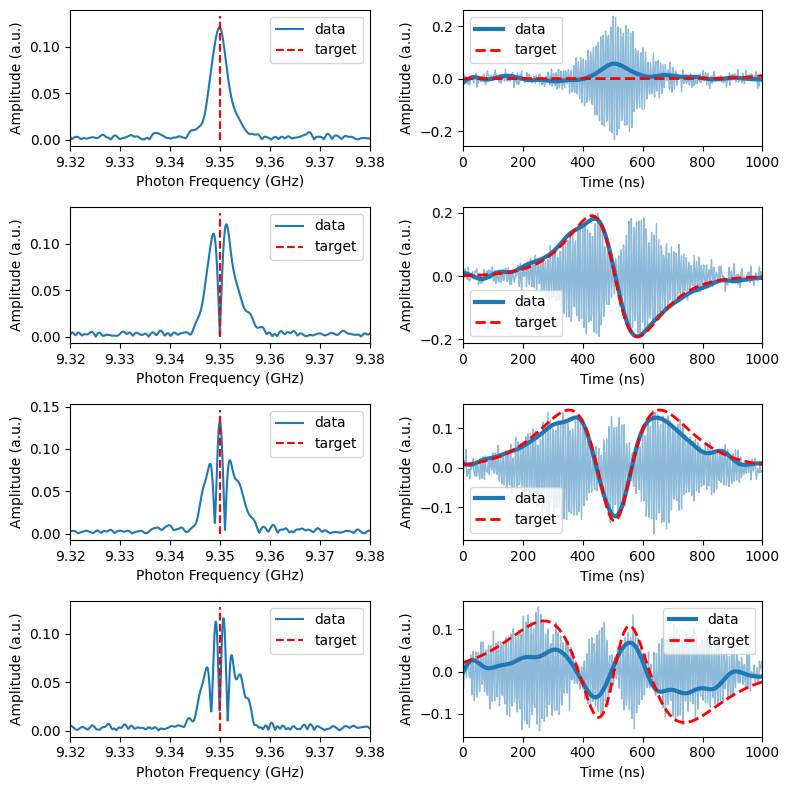

In [5]:
const = 2.5e-3*2*np.pi
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="103408", form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="103446", form="sech_1", center=510),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="103522", form="sech_2", center=510),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="103559", form="sech_3", center=510),
}

corrected_analyzer = SechPhotonAnalysis(data_path, corrected_result_dict, duration, const, readout_lo_freq)
corrected_analyzer.analyze_waveforms(passing_band, flipped=True)

Form: sech_0, Symmetry: 0.9782520176832245, Overlap: 0.9947987046709694
Form: sech_1, Symmetry: 0.9303909551427757, Overlap: 0.9916892841559959
Form: sech_2, Symmetry: 0.9002953450362546, Overlap: 0.9876555089895067
Form: sech_3, Symmetry: 0.8323495620693577, Overlap: 0.9696410391538908


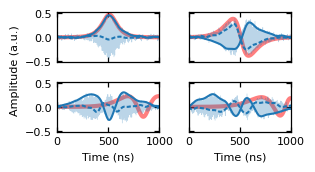

In [7]:
corrected_analyzer.analyze_waveforms_t(passing_band, flipped=True, dc=0)
# plt.savefig("photons.pdf")
# plt.savefig("photons.png", bbox_inches='tight')
plt.show()

fogi pulse generation for absoption

Saved Recieve_Pulse for data_sech_0 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_1 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_2 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_3 at D:\K_Sunada\result\control_pulses\CDK174\


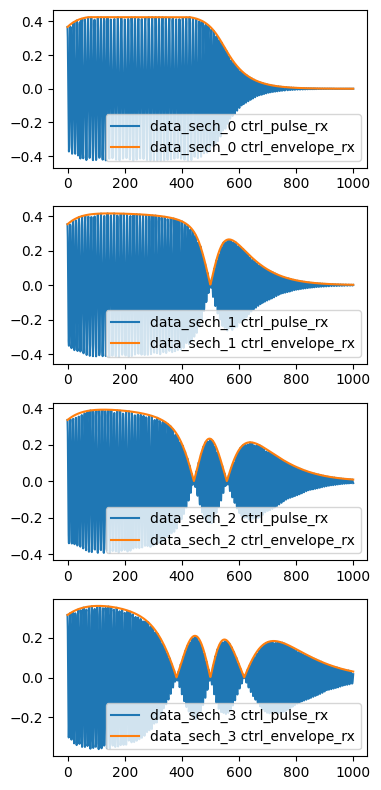

In [6]:
corrected_analyzer.generate_control_pulse_rx(ctrl_pulse_path)